# Bayesian Linear Regression Without Spatial Dependence

This notebook mirrors the data preparation and posterior workflow in `vecchia_spatial_regression.py`, but removes the spatial random field. The model is just

$$y_i = x_i^\top \beta + \epsilon_i, \quad \epsilon_i \sim N(0, \tau^2).$$

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

RANDOM_SEED = 305
rng = np.random.default_rng(RANDOM_SEED)

print(f"PyMC {pm.__version__} | ArviZ {az.__version__}")

PyMC 5.28.5 | ArviZ 0.23.4


## Configuration

In [2]:
DEFAULT_COVARIATES = (
    "prop_college_degree_or_higher_18plus",
    "election_diff",
    "log_contrib_2020",
    "log_income",
    "log_population",
)

INPUT_PATH = Path("../data/obs_chosen.csv")
TRACE_PATH = Path("trace_bayesian_nongeo.nc")
MODEL_DATA_PATH = Path("trace_bayesian_nongeo_model_data.npz")

TRAIN_FRAC = 0.8
SAMPLE_N = None
DRAWS = 1000
TUNE = 1000
CHAINS = 4
CORES = 1
TARGET_ACCEPT = 0.9
PPC_DRAWS = 500

## Data Preparation

In [3]:
@dataclass
class ModelData:
    X: np.ndarray
    y: np.ndarray
    covariates: tuple[str, ...]
    x_means: np.ndarray
    x_sds: np.ndarray


def train_test_split(df: pd.DataFrame, frac: float = 0.8, seed: int = 305):
    train = df.sample(frac=frac, random_state=seed)
    test = df.drop(train.index)
    return train.reset_index(drop=True), test.reset_index(drop=True)


def prepare_arrays(
    df: pd.DataFrame,
    covariates: tuple[str, ...] = DEFAULT_COVARIATES,
    sample_n: int | None = None,
    seed: int = 305,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    required = ["log_contrib_2022", *covariates]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data = df.dropna(subset=required).copy().reset_index(drop=True)
    if sample_n is not None and sample_n < len(data):
        data = data.sample(n=sample_n, random_state=seed).reset_index(drop=True)

    x_raw = data[list(covariates)].astype(float).to_numpy()
    x_means = x_raw.mean(axis=0)
    x_sds = x_raw.std(axis=0)
    x_sds[x_sds == 0] = 1.0

    x_scaled = (x_raw - x_means) / x_sds
    X = np.column_stack([np.ones(len(data)), x_scaled]).astype("float64")
    y = data["log_contrib_2022"].astype(float).to_numpy()
    return X, y, x_means, x_sds


def build_model_data(
    df: pd.DataFrame,
    covariates: tuple[str, ...] = DEFAULT_COVARIATES,
    sample_n: int | None = None,
    seed: int = 305,
) -> ModelData:
    X, y, x_means, x_sds = prepare_arrays(
        df=df,
        covariates=covariates,
        sample_n=sample_n,
        seed=seed,
    )
    return ModelData(
        X=X,
        y=y,
        covariates=tuple(covariates),
        x_means=x_means,
        x_sds=x_sds,
    )


def save_model_data(path: str | Path, data: ModelData) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        path,
        X=data.X,
        y=data.y,
        covariates=np.array(data.covariates, dtype=object),
        x_means=data.x_means,
        x_sds=data.x_sds,
    )


def load_model_data(path: str | Path) -> ModelData:
    z = np.load(path, allow_pickle=True)
    return ModelData(
        X=z["X"],
        y=z["y"],
        covariates=tuple(z["covariates"].tolist()),
        x_means=z["x_means"],
        x_sds=z["x_sds"],
    )

In [4]:
df = pd.read_csv(INPUT_PATH)
train_df, test_df = train_test_split(df, frac=TRAIN_FRAC, seed=RANDOM_SEED)
data = build_model_data(
    train_df,
    covariates=DEFAULT_COVARIATES,
    sample_n=SAMPLE_N,
    seed=RANDOM_SEED,
)

print(f"Input rows: {len(df):,}")
print(f"Train rows before drop/sample: {len(train_df):,}")
print(f"Model rows: {len(data.y):,}")
print(f"X shape: {data.X.shape}")
print(f"y mean={data.y.mean():.3f}, y sd={data.y.std():.3f}")

Input rows: 5,145
Train rows before drop/sample: 4,116
Model rows: 4,116
X shape: (4116, 6)
y mean=8.182, y sd=1.883


## Bayesian Linear Model

In [5]:
def build_bayesian_linear_model(
    data: ModelData,
    *,
    beta_sigma: float = 5.0,
    log_tau2_sigma: float = 5.0,
) -> pm.Model:
    with pm.Model() as model:
        X = pm.Data("X", data.X)
        beta = pm.Normal("beta", mu=0.0, sigma=beta_sigma, shape=data.X.shape[1])

        log_tau2 = pm.Normal("log_tau2", mu=0.0, sigma=log_tau2_sigma)
        tau2 = pm.Deterministic("tau2", pt.exp(log_tau2))
        tau = pm.Deterministic("tau", pt.sqrt(tau2))

        mu = pm.Deterministic("mu", pm.math.dot(X, beta))
        pm.Normal("y_obs", mu=mu, sigma=tau, observed=data.y)

    return model


model = build_bayesian_linear_model(data)
model

    beta ~ Normal(0, 5)
log_tau2 ~ Normal(0, 5)
    tau2 ~ Deterministic(f(log_tau2))
     tau ~ Deterministic(f(log_tau2))
      mu ~ Deterministic(f(beta))
   y_obs ~ Normal(mu, tau)

In [6]:
with model:
    idata = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        cores=CORES,
        target_accept=TARGET_ACCEPT,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
    )

idata.attrs["model"] = "bayesian_linear_regression_no_spatial_dependence"
idata.attrs["n_observations"] = int(data.y.shape[0])
idata.attrs["covariates"] = ",".join(data.covariates)

save_model_data(MODEL_DATA_PATH, data)
az.to_netcdf(idata, TRACE_PATH)
print(f"Saved trace: {TRACE_PATH}")
print(f"Saved model data: {MODEL_DATA_PATH}")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [beta, log_tau2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Saved trace: trace_bayesian_nongeo.nc
Saved model data: trace_bayesian_nongeo_model_data.npz


## Diagnostics

In [7]:
summary = az.summary(idata, var_names=["beta", "tau2", "tau"], hdi_prob=0.95)
print(summary.round(3).to_string())

coef_labels = ["intercept", *data.covariates]
beta_summary = az.summary(idata, var_names=["beta"], hdi_prob=0.95)
beta_summary.index = coef_labels
beta_summary[["mean", "sd", "hdi_2.5%", "hdi_97.5%", "r_hat", "ess_bulk"]].round(3)

          mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
beta[0]  8.182  0.017     8.149      8.215      0.000      0.0    4533.0    3057.0    1.0
beta[1]  0.560  0.029     0.502      0.616      0.001      0.0    2417.0    2892.0    1.0
beta[2]  0.379  0.018     0.344      0.412      0.000      0.0    4075.0    2824.0    1.0
beta[3]  0.883  0.028     0.831      0.939      0.001      0.0    2487.0    2950.0    1.0
beta[4] -0.161  0.024    -0.208     -0.115      0.000      0.0    2841.0    2725.0    1.0
beta[5]  0.451  0.021     0.408      0.492      0.000      0.0    3107.0    2966.0    1.0
tau2     1.192  0.026     1.144      1.246      0.000      0.0    4231.0    3272.0    1.0
tau      1.092  0.012     1.070      1.116      0.000      0.0    4231.0    3272.0    1.0


,mean,sd,hdi_2.5%,hdi_97.5%,r_hat,ess_bulk
intercept,8.182,0.017,8.149,8.215,1.0,4533.0
prop_college_degree_or_higher_18plus,0.560,0.029,0.502,0.616,1.0,2417.0
election_diff,0.379,0.018,0.344,0.412,1.0,4075.0
log_contrib_2020,0.883,0.028,0.831,0.939,1.0,2487.0
log_income,-0.161,0.024,-0.208,-0.115,1.0,2841.0
log_population,0.451,0.021,0.408,0.492,1.0,3107.0


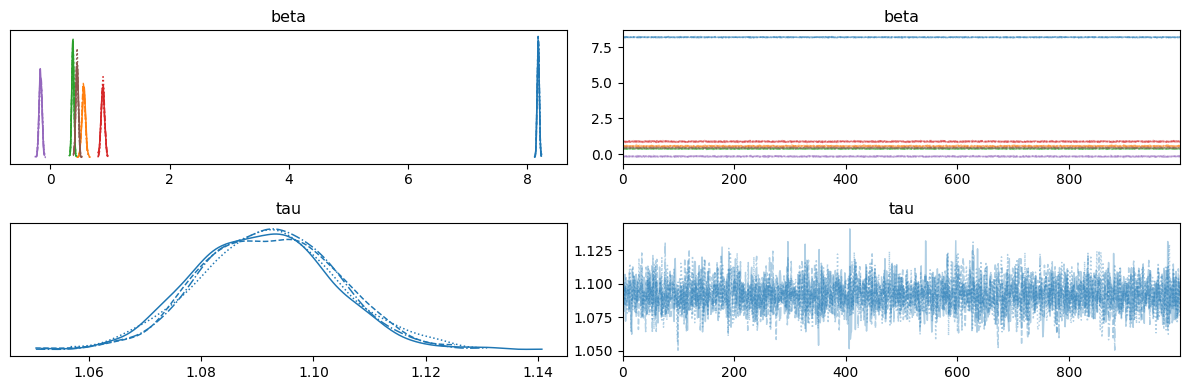

In [8]:
az.plot_trace(idata, var_names=["beta", "tau"], compact=True)
plt.tight_layout()
plt.savefig("nongeo_trace.png", dpi=120, bbox_inches="tight")
plt.show()

## Posterior Predictive Checks

In [9]:
def posterior_draw_table(idata: az.InferenceData) -> pd.DataFrame:
    posterior = idata.posterior.stack(sample=("chain", "draw"))
    beta = posterior["beta"].transpose("sample", "beta_dim_0").values
    out = pd.DataFrame(beta, columns=[f"beta_{j}" for j in range(beta.shape[1])])
    out["tau2"] = posterior["tau2"].values
    out["tau"] = posterior["tau"].values
    return out


def add_posterior_predictive(
    idata: az.InferenceData,
    data: ModelData,
    *,
    ppc_draws: int,
    seed: int = 306,
) -> az.InferenceData:
    if ppc_draws <= 0:
        return idata

    draws = posterior_draw_table(idata)
    rng = np.random.default_rng(seed)
    chosen = rng.choice(len(draws), size=min(ppc_draws, len(draws)), replace=False)

    y_rep = np.empty((1, len(chosen), data.y.shape[0]), dtype="float64")
    beta_cols = [c for c in draws.columns if c.startswith("beta_")]
    for j, row_id in enumerate(chosen):
        row = draws.iloc[row_id]
        beta = row[beta_cols].to_numpy(dtype="float64")
        mu = data.X @ beta
        y_rep[0, j, :] = rng.normal(mu, float(row["tau"]))

    ds = xr.Dataset(
        data_vars={"y_rep": (("chain", "draw", "obs_id"), y_rep)},
        coords={
            "chain": [0],
            "draw": np.arange(y_rep.shape[1]),
            "obs_id": np.arange(data.y.shape[0]),
        },
    )

    if hasattr(idata, "posterior_predictive"):
        idata.posterior_predictive = ds
    else:
        idata.add_groups({"posterior_predictive": ds})
    return idata


idata = add_posterior_predictive(
    idata,
    data,
    ppc_draws=PPC_DRAWS,
    seed=RANDOM_SEED + 1,
)
az.to_netcdf(idata, TRACE_PATH)
idata.posterior_predictive

<xarray.Dataset> Size: 17MB
Dimensions:  (chain: 1, draw: 500, obs_id: 4116)
Coordinates:
  * chain    (chain) int64 8B 0
  * draw     (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
  * obs_id   (obs_id) int64 33kB 0 1 2 3 4 5 6 ... 4110 4111 4112 4113 4114 4115
Data variables:
    y_rep    (chain, draw, obs_id) float64 16MB 8.936 3.457 ... 9.684 7.081

In [10]:
y_rep = idata.posterior_predictive["y_rep"].values.reshape(-1, data.y.shape[0])
y_pred_mean = y_rep.mean(axis=0)
resid = data.y - y_pred_mean

rmse = np.sqrt(np.mean(resid**2))
mae = np.mean(np.abs(resid))
coverage_90 = np.mean(
    (data.y >= np.quantile(y_rep, 0.05, axis=0))
    & (data.y <= np.quantile(y_rep, 0.95, axis=0))
)

print(f"Posterior predictive RMSE: {rmse:.3f}")
print(f"Posterior predictive MAE:  {mae:.3f}")
print(f"90% interval coverage:     {coverage_90:.3f}")

Posterior predictive RMSE: 1.091
Posterior predictive MAE:  0.823
90% interval coverage:     0.896


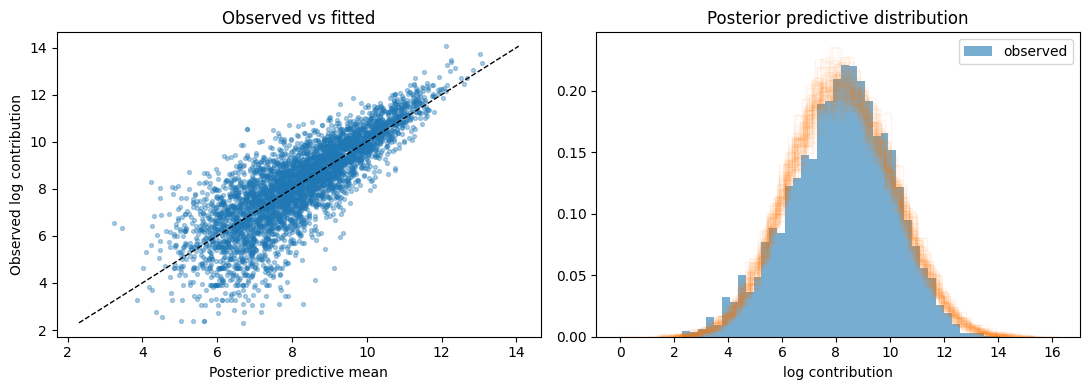

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(y_pred_mean, data.y, s=8, alpha=0.35)
lo = min(y_pred_mean.min(), data.y.min())
hi = max(y_pred_mean.max(), data.y.max())
axes[0].plot([lo, hi], [lo, hi], color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("Posterior predictive mean")
axes[0].set_ylabel("Observed log contribution")
axes[0].set_title("Observed vs fitted")

axes[1].hist(data.y, bins=40, alpha=0.6, density=True, label="observed")
for draw in y_rep[:50]:
    axes[1].hist(draw, bins=40, density=True, histtype="step", color="C1", alpha=0.08)
axes[1].set_xlabel("log contribution")
axes[1].set_title("Posterior predictive distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig("nongeo_ppc.png", dpi=150, bbox_inches="tight")
plt.show()

## Held-Out Test MSE

In [12]:
def prepare_test_arrays(
    df: pd.DataFrame,
    train_data: ModelData,
) -> tuple[np.ndarray, np.ndarray]:
    required = ["log_contrib_2022", *train_data.covariates]
    test = df.dropna(subset=required).copy().reset_index(drop=True)

    x_raw = test[list(train_data.covariates)].astype(float).to_numpy()
    x_scaled = (x_raw - train_data.x_means) / train_data.x_sds
    X_test = np.column_stack([np.ones(len(test)), x_scaled]).astype("float64")
    y_test = test["log_contrib_2022"].astype(float).to_numpy()
    return X_test, y_test


X_test, y_test = prepare_test_arrays(test_df, data)

draws = posterior_draw_table(idata)
beta_cols = [c for c in draws.columns if c.startswith("beta_")]
beta_mean = draws[beta_cols].mean(axis=0).to_numpy(dtype="float64")
y_test_pred = X_test @ beta_mean
test_resid = y_test - y_test_pred
test_mse = np.mean(test_resid**2)
test_rmse = np.sqrt(test_mse)

print(f"Test rows: {len(y_test):,}")
print(f"Test MSE:  {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Test rows: 1,029
Test MSE:  1.1626
Test RMSE: 1.0782


## Coefficient Table

In [ ]:
coef = beta_summary[["mean", "sd", "hdi_2.5%", "hdi_97.5%"]].copy()
coef.index.name = "term"
coef.to_csv("nongeo_beta_posterior_summary.csv")
coef.round(4)